<a href="https://colab.research.google.com/github/jain726/Predictive-Modeling-of-Liver-Cell-Mechanics/blob/Deep_Learning/Multi_Layer_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Fold 1 ---


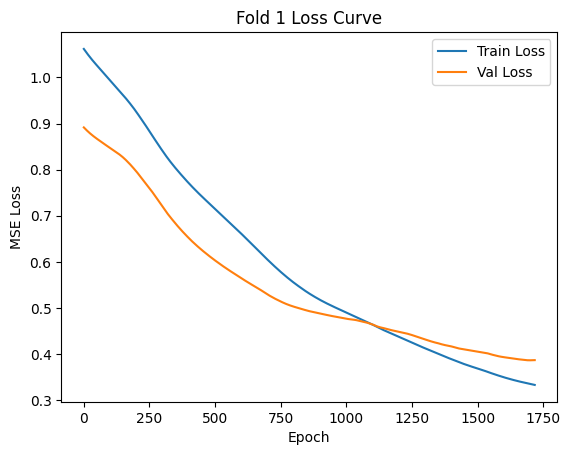


--- Fold 2 ---


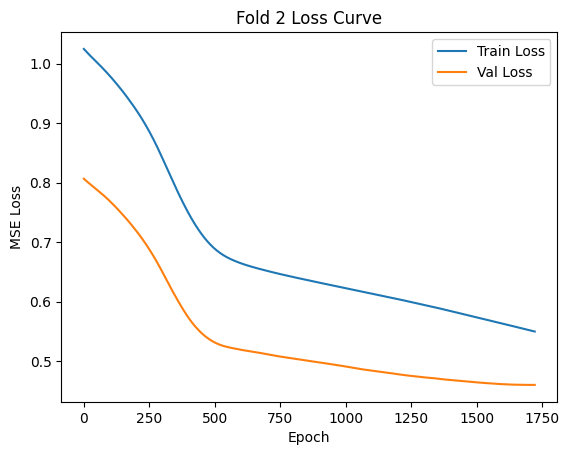


--- Fold 3 ---


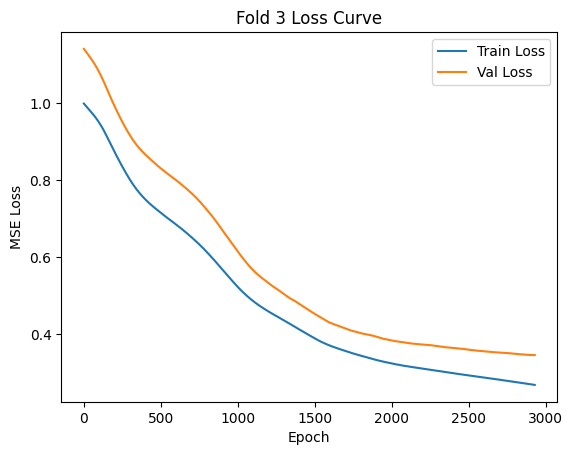


--- Fold 4 ---


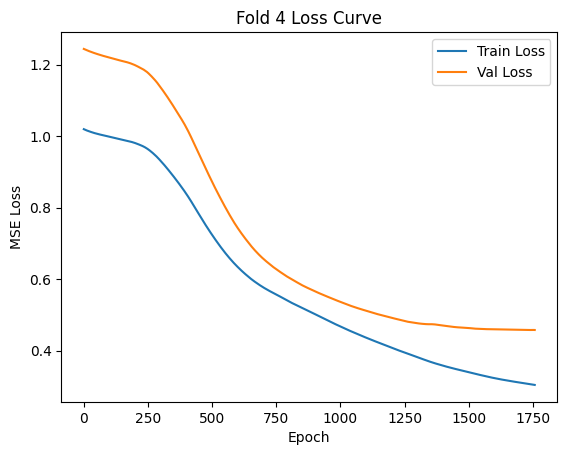


--- Fold 5 ---


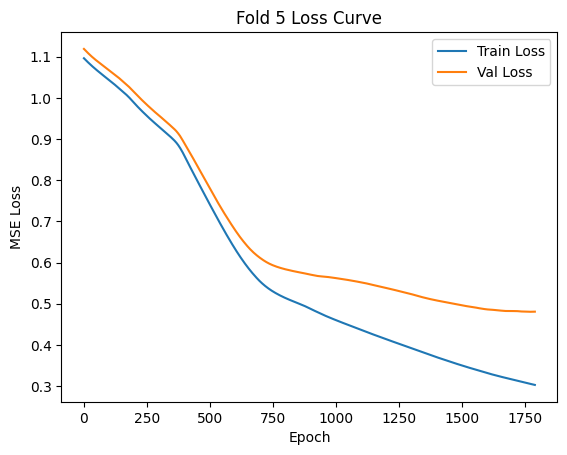


--- 5-Fold Grouped CV Results ---
R²:  0.5623 ± 0.0929
MSE: 0.000040 ± 0.000005
MAE: 0.005076 ± 0.000322


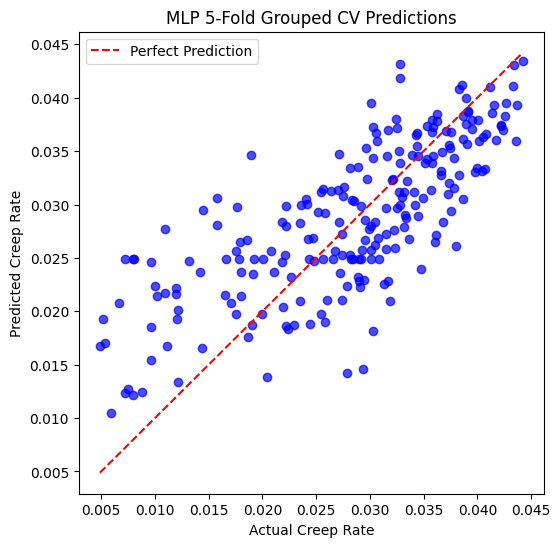

Train features saved to train_features_all_layers.csv
Validation features saved to val_features_all_layers.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
%matplotlib inline

# -----------------------------
# Define MLP Model with feature extraction
# -----------------------------
class Model(nn.Module):
    def __init__(self, in_features=5, h1=32, h2=16, h3=8, out_features=1):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, h3)
        self.out = nn.Linear(h3, out_features)

    def forward(self, x):
        x1 = F.relu(self.fc1(x))
        x2 = F.relu(self.fc2(x1))
        x3 = F.relu(self.fc3(x2))
        out = self.out(x3)
        return out

    def extract_features(self, x):
        """Concatenate activations from all hidden layers for downstream ML"""
        x1 = F.relu(self.fc1(x))
        x2 = F.relu(self.fc2(x1))
        x3 = F.relu(self.fc3(x2))
        return torch.cat([x1, x2, x3], dim=1)  # shape: (n_samples, h1+h2+h3)

# -----------------------------
# Load Data
# -----------------------------
features = pd.read_csv("/content/combined_features_243.csv")
results = pd.read_csv("/content/creep_results_243.csv")
data = features.merge(results, left_on='filename', right_on='File Name')

# -----------------------------
# Define X, y and groups
# -----------------------------
X = data.drop(columns=[
    'File Name', 'filename', 'Creep Rate', 'Permanent Strain',
    'num_nodes', 'num_edges', 'avg_edge_length', 'max_node_degree',
    'graph_density', 'num_junctions', 'num_branches',
    'avg_branch_length', 'total_filament_length', 'filament_density',
    'std_orientation'
]).values

y = data['Creep Rate'].values.reshape(-1,1)
groups = data['File Name'].str.replace(r'_images\d+', '', regex=True).values

# -----------------------------
# Grouped 5-Fold Cross-Validation
# -----------------------------
gkf = GroupKFold(n_splits=5)

r2_scores = []
mse_scores = []
mae_scores = []

all_y_true = []
all_y_pred = []

# Store features for all folds
all_train_features = []
all_val_features = []
all_train_file_names = []
all_val_file_names = []

torch.manual_seed(41)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    print(f"\n--- Fold {fold+1} ---")

    # Split
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    # Scale X
    x_scaler = StandardScaler()
    X_tr_scaled = x_scaler.fit_transform(X_tr)
    X_val_scaled = x_scaler.transform(X_val)

    # Scale y
    y_scaler = StandardScaler()
    y_tr_scaled = y_scaler.fit_transform(y_tr)
    y_val_scaled = y_scaler.transform(y_val)

    # Convert to torch tensors
    X_tr_t = torch.FloatTensor(X_tr_scaled)
    X_val_t = torch.FloatTensor(X_val_scaled)
    y_tr_t = torch.FloatTensor(y_tr_scaled)
    y_val_t = torch.FloatTensor(y_val_scaled)

    # Initialize model
    model = Model(in_features=X_tr_t.shape[1])
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

    # Early stopping parameters
    best_val_loss = float('inf')
    patience = 20
    counter = 0
    best_state = None

    # Training loop
    epochs = 5000
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_tr_t)
        loss = criterion(outputs, y_tr_t)
        loss.backward()
        optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        # Early stopping check
        if val_loss.item() < best_val_loss - 1e-6:
            best_val_loss = val_loss.item()
            counter = 0
            best_state = model.state_dict()
        else:
            counter += 1

        if counter >= patience:
            break

    # Restore best model
    model.load_state_dict(best_state)
    model.eval()

    # -----------------------------
    # Extract features from all layers for downstream ML
    # -----------------------------
    with torch.no_grad():
        X_tr_features = model.extract_features(X_tr_t).numpy()
        X_val_features = model.extract_features(X_val_t).numpy()

    all_train_features.append(X_tr_features)
    all_val_features.append(X_val_features)

    # Store corresponding file names
    all_train_file_names.append(data['File Name'].iloc[train_idx].values)
    all_val_file_names.append(data['File Name'].iloc[val_idx].values)

    # Evaluate on validation set (inverse-transform)
    with torch.no_grad():
        y_val_pred_scaled = model(X_val_t).numpy()
    y_val_pred = y_scaler.inverse_transform(y_val_pred_scaled)

    # Store metrics
    r2_scores.append(r2_score(y_val, y_val_pred))
    mse_scores.append(mean_squared_error(y_val, y_val_pred))
    mae_scores.append(mean_absolute_error(y_val, y_val_pred))

    # Store predictions for plotting later
    all_y_true.append(y_val)
    all_y_pred.append(y_val_pred)

    # Optional: plot fold losses
    plt.figure()
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(f'Fold {fold+1} Loss Curve')
    plt.legend()
    plt.show()

# -----------------------------
# Final CV Metrics
# -----------------------------
print("\n--- 5-Fold Grouped CV Results ---")
print(f"R²:  {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"MSE: {np.mean(mse_scores):.6f} ± {np.std(mse_scores):.6f}")
print(f"MAE: {np.mean(mae_scores):.6f} ± {np.std(mae_scores):.6f}")

# -----------------------------
# Plot Predicted vs Actual
# -----------------------------
all_y_true = np.vstack(all_y_true)
all_y_pred = np.vstack(all_y_pred)

plt.figure(figsize=(6,6))
plt.scatter(all_y_true, all_y_pred, color='blue', alpha=0.7)
plt.plot([all_y_true.min(), all_y_true.max()],
         [all_y_true.min(), all_y_true.max()],
         color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual Creep Rate")
plt.ylabel("Predicted Creep Rate")
plt.title("MLP 5-Fold Grouped CV Predictions")
plt.legend()
plt.show()

# -----------------------------
# Concatenate features and file names across folds
# -----------------------------
all_train_features = np.vstack(all_train_features)
all_val_features = np.vstack(all_val_features)
all_train_file_names = np.concatenate(all_train_file_names)
all_val_file_names = np.concatenate(all_val_file_names)

# Generate column names
h1, h2, h3 = 32, 16, 8
layer1_cols = [f"layer1_feat{i+1}" for i in range(h1)]
layer2_cols = [f"layer2_feat{i+1}" for i in range(h2)]
layer3_cols = [f"layer3_feat{i+1}" for i in range(h3)]
all_feature_cols = layer1_cols + layer2_cols + layer3_cols
all_cols = ["File Name"] + all_feature_cols

# Create DataFrames with proper structure
train_features_df = pd.DataFrame(
    np.hstack([all_train_file_names.reshape(-1,1), all_train_features]),
    columns=all_cols
)

val_features_df = pd.DataFrame(
    np.hstack([all_val_file_names.reshape(-1,1), all_val_features]),
    columns=all_cols
)

# Save CSV
train_csv_path = "train_features_all_layers.csv"
val_csv_path = "val_features_all_layers.csv"
train_features_df.to_csv(train_csv_path, index=False)
val_features_df.to_csv(val_csv_path, index=False)

print(f"Train features saved to {train_csv_path}")
print(f"Validation features saved to {val_csv_path}")

# Optionally download in Colab
from google.colab import files
files.download(train_csv_path)
files.download(val_csv_path)
